# Circular Task Assignment: Mouse Trajectory Analysis

## Objective:
Analyze mouse trajectory data from circular steering tasks:
1. Load and display metadata about each recording
2. Extract recording intervals and compute timing information
3. Plot raw trajectory data (time series and spatial)
4. Compute performance metrics (Re, Te, error, nLaps, MT, IDe, Be, IPe)
5. Visualize individual recording segments

## Workflow:
- Imports
- Configuration constants
- Data loading functions
- Computation functions
- Plotting functions
- Main execution workflow

In [95]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

In [96]:
# ============================================================================
# CONFIGURATION / CONSTANTS
# ============================================================================

# Constants for analysis
TE_MULTIPLIER = 4.1326            # Empirical: Te = TE_MULTIPLIER * std(radial, ddof=1)
MIN_REQUIRED_COLUMNS = 4          # time, x, y, insideFlag

# File names
DATA_FILE_NAME = "001MoDe_R1.csv"
MARKER_FILE_NAME = "001MoDe_R1.marker.csv"

# Repository configuration
REPO_NAME = 'Circular-task-assignement-Savona-Singer-Virolan'

In [97]:
# ============================================================================
# FUNCTIONS: PATH RESOLUTION
# ============================================================================

def find_repo_root(repo_name=REPO_NAME):
    """Walk up directory tree until we find the repository folder"""
    current = os.getcwd()
    while current != os.path.dirname(current):  # Stop at filesystem root
        if os.path.basename(current) == repo_name:
            return current
        current = os.path.dirname(current)
    return os.getcwd()  # Fallback to current directory


def resolve_data_dir():
    """Find data directory relative to repository root"""
    repo_root = find_repo_root()
    data_dir = os.path.join(repo_root, 'data')
    if not os.path.exists(data_dir):
        raise FileNotFoundError(f"Could not locate data directory at: {data_dir}")
    return data_dir

In [98]:
# ============================================================================
# FUNCTIONS: METADATA AND DATA LOADING
# ============================================================================

def load_task_parameters(file_path):
    """
    Parse first line of raw CSV for task parameters.
    Expected format: key value;key value;...
    Returns dict with centerX, centerY, taskRadius, taskTolerance, 
    internalRadius, externalRadius
    """
    with open(file_path, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()
    
    params = {}
    for entry in first_line.split(";"):
        tokens = entry.split()
        if len(tokens) != 2:
            continue
        k, v = tokens
        try:
            params[k] = float(v)
        except ValueError:
            continue
    
    required = ["centerX", "centerY", "taskRadius", "taskTolerance"]
    missing = [r for r in required if r not in params]
    if missing:
        raise ValueError(f"Missing required metadata fields: {missing}")
    return params


def read_markers(file_path):
    """
    Read marker file, handle multiline labels (blank line terminates).
    Returns dict with 'timestamps' and 'labels' arrays.
    """
    timestamps = []
    labels = []
    
    with open(file_path, "r", encoding="utf-8") as f:
        # Skip header block until empty line
        for line in f:
            if line.strip() == "":
                break
        
        multiline_mode = False
        multiline_ts = None
        multiline_label = ""
        
        for line in f:
            raw = line.rstrip("\n")
            
            if multiline_mode:
                if raw.strip() == "":
                    timestamps.append(multiline_ts)
                    labels.append(multiline_label.rstrip("\n"))
                    multiline_mode = False
                else:
                    multiline_label += raw + "\n"
                continue
            
            parts = raw.split(",")
            if len(parts) < 3:
                continue
            
            # parts[1] = timestamp, parts[2] = label
            try:
                ts = float(parts[1])
            except ValueError:
                continue
            
            lab = parts[2]
            if lab == "":
                multiline_mode = True
                multiline_ts = ts
                multiline_label = ""
            else:
                timestamps.append(ts)
                labels.append(lab)
        
        if multiline_mode:
            timestamps.append(multiline_ts)
            labels.append(multiline_label.rstrip("\n"))
    
    if len(timestamps) == 0:
        raise ValueError(f"No markers parsed from {file_path}")
    
    # Strip whitespace from labels
    labels = [label.strip() for label in labels]
    
    return {
        "timestamps": np.array(timestamps, dtype=float),
        "labels": np.array(labels, dtype=str)
    }


def is_numeric_line(line):
    """Check if line contains numeric data (at least 4 columns)"""
    parts = line.strip().split(",")
    if len(parts) < MIN_REQUIRED_COLUMNS:
        return False
    try:
        for i in range(4):
            float(parts[i])
        return True
    except ValueError:
        return False


def load_raw_trajectory(file_path):
    """
    Load numeric portion of the CSV (skips metadata/header lines).
    Returns (time_ms, x, y, inside_flag).
    """
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    
    numeric_lines = [ln for ln in lines if is_numeric_line(ln)]
    if len(numeric_lines) == 0:
        raise ValueError("No numeric lines retained. Check CSV format.")
    
    # Parse manually
    data = []
    for line in numeric_lines:
        parts = line.strip().split(",")
        row = [float(parts[i]) for i in range(MIN_REQUIRED_COLUMNS)]
        data.append(row)
    
    data = np.array(data)
    
    if data.ndim == 1:
        data = data.reshape(1, -1)
    if data.shape[1] < MIN_REQUIRED_COLUMNS:
        raise ValueError(f"Data has {data.shape[1]} columns (< {MIN_REQUIRED_COLUMNS} required).")
    
    time_ms = data[:, 0]
    x = data[:, 1]
    y = data[:, 2]
    inside_flag = data[:, 3].astype(bool)
    return time_ms, x, y, inside_flag

In [99]:
# ============================================================================
# FUNCTIONS: INTERVAL AND TIMING COMPUTATIONS
# ============================================================================

def find_record_pause_markers(markers):
    """Find indices of markers containing DoRecord or DoPause"""
    record_pause_indices = []
    for i, (timestamp, label) in enumerate(zip(markers["timestamps"], markers["labels"])):
        if 'DoRecord' in label or 'DoPause' in label:
            record_pause_indices.append(i)
    return record_pause_indices


def extract_record_intervals(markers, t0_ms):
    """
    Extract recording intervals from markers.
    Returns list of (start_s, end_s) tuples relative to t0_ms.
    """
    timestamps = markers["timestamps"]
    labels = markers["labels"]
    intervals = []
    current_rec_ts = None
    
    for timestamp, label in zip(timestamps, labels):
        if "DoRecord" in label:
            current_rec_ts = timestamp
        elif "DoPause" in label and current_rec_ts is not None:
            start_s = (current_rec_ts - t0_ms) / 1000.0
            end_s = (timestamp - t0_ms) / 1000.0
            if end_s > start_s:
                intervals.append((start_s, end_s))
            current_rec_ts = None
        
        # Stop early if all recordings complete
        if "RecordDone=" in label and "ToDo=" in label:
            try:
                done_pos = label.find("RecordDone=")
                todo_pos = label.find("ToDo=")
                done_str = label[done_pos + 11:].split()[0]
                todo_str = label[todo_pos + 5:].split()[0]
                done = int(done_str)
                todo = int(todo_str)
                if done >= todo:
                    break
            except Exception:
                pass
    
    if len(intervals) == 0:
        raise ValueError("No valid intervals parsed.")
    return intervals


def calculate_interval_durations(intervals):
    """Calculate durations for each interval"""
    return np.array([end - start for start, end in intervals])


def compute_sampling_frequency(time_s, intervals):
    """
    Compute sampling frequency for each recording interval.
    Returns list of (interval_idx, n_samples, duration_s, freq_hz) tuples.
    """
    freq_stats = []
    for i, (start, end) in enumerate(intervals):
        mask = (time_s >= start) & (time_s <= end)
        n_samples = np.count_nonzero(mask)
        duration = end - start
        freq = n_samples / duration if duration > 0 else 0
        freq_stats.append((i + 1, n_samples, duration, freq))
    return freq_stats

In [100]:
# ============================================================================
# FUNCTIONS: DISPLAY/PRINT FUNCTIONS
# ============================================================================

def display_metadata(raw_file_path, marker_file_path, params, markers, results=None):
    """Display header information, markers, and results table"""
    # Show recording information
    print(f"Header line information in '{raw_file_path}':")
    for key, value in params.items():
        print(f"{key}: {value}")
    
    # Display markers
    print(f"\nMarkers in '{marker_file_path}':")
    for timestamp, label in zip(markers["timestamps"], markers["labels"]):
        # Only show single-line labels to avoid clutter
        if '\n' not in label:
            print(f"{timestamp}: {label}")
    
    # Display results if provided (from old code structure)
    if results is not None:
        print("\nResults table:")
        for row in results:
            print(' '.join(row))


def display_record_times_absolute(markers, record_pause_indices, durations):
    """Display record times in absolute timestamps (Unix epoch)"""
    print("\nrecord times (milliseconds since the Unix epoch, 00:00:00 UTC on January 1, 1970):")
    for i in range(0, len(durations), 2):  # Step by 2 to get only records
        idx_start = record_pause_indices[i]
        idx_end = record_pause_indices[i + 1]
        marker_start = markers["timestamps"][idx_start]
        marker_end = markers["timestamps"][idx_end]
        duration_s = durations[i]
        print(f"{marker_start:.0f} to {marker_end:.0f} ({duration_s:.3f} s)")


def display_record_times_relative(time_ms, markers, record_pause_indices, durations):
    """Display record times relative to first DoRecord marker"""
    first_dorecord = time_ms[0] / 1000  # Convert first recorded value timestamp to seconds
    marker_start_rels = []
    marker_end_rels = []
    
    print("\nrecord times (seconds since the first DoRecord marker):")
    
    for i in range(0, len(durations), 2):  # Step by 2 to get only records
        idx_start = record_pause_indices[i]
        idx_end = record_pause_indices[i + 1]
        marker_start_rel = (markers["timestamps"][idx_start] / 1000) - first_dorecord
        marker_end_rel = (markers["timestamps"][idx_end] / 1000) - first_dorecord
        duration_s = marker_end_rel - marker_start_rel
        print(f"{marker_start_rel:7.3f} to {marker_end_rel:7.3f} ({duration_s:.3f} s)")
        marker_start_rels.append(marker_start_rel)
        marker_end_rels.append(marker_end_rel)
    
    return marker_start_rels, marker_end_rels

In [101]:
# ============================================================================
# FUNCTIONS: METRICS COMPUTATION
# ============================================================================

def compute_metrics(time_s, x_centered, y_centered, radial_dist, inside_flag, task_tolerance):
    """
    Compute circular steering metrics after first inside event.
    Returns dict with Re, Te, error, nLaps, MT, IDe, Be, IPe.
    """
    idx_inside = np.where(inside_flag)[0]
    if len(idx_inside) == 0:
        return None
    start_idx = idx_inside[0]
    
    # Filter data from first inside event
    t_filtered = time_s[start_idx:]
    x_filtered = x_centered[start_idx:]
    y_filtered = y_centered[start_idx:]
    dist_filtered = radial_dist[start_idx:]
    inside_filtered = inside_flag[start_idx:]
    
    # Compute Re and Te
    Re = np.mean(dist_filtered)
    Te = TE_MULTIPLIER * np.std(dist_filtered, ddof=1)
    
    # Compute angular metrics
    # y_filtered is in screen coordinates (down is positive)
    # Use -y to convert to standard math coordinates (up is positive)
    theta = np.arctan2(-y_filtered, x_filtered)
    dtheta = np.diff(theta)
    # Phase unwrap
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi
    abs_dtheta = np.abs(dtheta)
    
    if len(abs_dtheta) == 0:
        return {
            "Re": Re, "Te": Te, "error": np.nan,
            "nLaps": 0.0, "MT": np.nan, "IDe": np.nan,
            "Be": Te / task_tolerance if task_tolerance > 0 else np.nan,
            "IPe": np.nan
        }
    
    # Calculate error as percentage of time/angle spent outside the target
    outside_segments = ~inside_filtered[:-1]
    total_angle = np.sum(abs_dtheta)
    outside_angle = np.sum(abs_dtheta[outside_segments])
    error_percentage = (outside_angle / total_angle * 100) if total_angle > 0 else 0
    
    # Calculate signed total angle to preserve direction (negative = clockwise)
    signed_total_angle = np.sum(dtheta)
    nLaps = signed_total_angle / (2 * np.pi)
    
    duration = t_filtered[-1] - t_filtered[0]
    MT = duration / abs(nLaps) if nLaps != 0 else np.nan
    
    IDe = (2 * np.pi * Re) / Te if Te > 0 else np.nan
    Be = Te / task_tolerance if task_tolerance > 0 else np.nan
    IPe = IDe / MT if (MT > 0 and not np.isnan(MT) and not np.isnan(IDe)) else np.nan
    
    return {
        "Re": Re,
        "Te": Te,
        "error": error_percentage,
        "nLaps": nLaps,
        "MT": MT,
        "IDe": IDe,
        "Be": Be,
        "IPe": IPe
    }

In [102]:
# ============================================================================
# FUNCTIONS: PLOTTING
# ============================================================================

def plot_all_data_timeseries(time_s, x_centered, y_centered, intervals):
    """
    Plot raw time series data with record boundaries.
    Shows x and y positions over time with vertical lines marking intervals.
    """
    # Filter data to only include points within record boundaries
    mask = np.zeros(len(time_s), dtype=bool)
    for start, end in intervals:
        mask |= (time_s >= start) & (time_s <= end)
    
    time_filtered = time_s[mask]
    x_filtered = x_centered[mask]
    y_filtered = y_centered[mask]
    
    # Determine height of vertical lines
    ymin_val = min(min(x_filtered), min(y_filtered))
    ymax_val = max(max(x_filtered), max(y_filtered))
    
    # Create plot with original style
    plt.figure(figsize=(20, 6))
    plt.plot(time_filtered, x_filtered, label='x position', color='blue', 
             linestyle='None', marker='o', markersize=1.5)
    plt.plot(time_filtered, y_filtered, label='y position', color='orange', 
             linestyle='None', marker='o', markersize=1.5)
    
    # Plot interval boundaries
    starts = [s for s, _ in intervals]
    ends = [e for _, e in intervals]
    plt.vlines(starts, ymin=ymin_val, ymax=ymax_val, colors='black', 
               linestyles='dashed', label='record start')
    plt.vlines(ends, ymin=ymin_val, ymax=ymax_val, colors='red', 
               linestyles='dashed', label='record end')
    
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.title('Raw time series data')
    plt.legend(loc='upper center')
    plt.show()


def plot_all_data_spatial(x_centered, y_centered, inside_flag):
    """
    Plot raw trajectory on spatial plane with target annulus.
    Shows complete trajectory with inside/outside target regions.
    """
    plt.figure(figsize=(6, 6))
    
    # Flip y-coordinates for spatial plot (upside down)
    y_flipped = -y_centered
    
    # Compute radii only for inside-target samples
    r_inside = np.sqrt(x_centered[inside_flag]**2 + y_flipped[inside_flag]**2)
    
    # Compute empirical radii
    inner_r = r_inside.min()
    outer_r = r_inside.max()
    
    theta = np.linspace(0, 2*np.pi, 512)
    circle_inner_x = inner_r * np.cos(theta)
    circle_inner_y = inner_r * np.sin(theta)
    circle_outer_x = outer_r * np.cos(theta)
    circle_outer_y = outer_r * np.sin(theta)
    
    outside_mask = ~inside_flag
    
    # Construct trajectory with discontinuities to avoid lines through target
    x_traj = x_centered[outside_mask].copy()
    y_traj = y_flipped[outside_mask].copy()
    
    # Threshold for cutting the line (in pixels)
    jump_threshold = 30  # pixels, removes unrealistic fast movements
    
    for i in range(1, len(x_traj)): 
        dx = x_traj[i] - x_traj[i-1]
        dy = y_traj[i] - y_traj[i-1]
        if np.hypot(dx, dy) > jump_threshold:
            x_traj[i] = np.nan  # Insert NaN to break the line
            y_traj[i] = np.nan
    
    TRAJECTORY_COLOR = "#277cb6"  # Blue color matching reference paper
    
    # Plot trajectory (outside target)
    plt.plot(x_traj, y_traj, color=TRAJECTORY_COLOR, linewidth=1, label="trajectory")
    
    # Plot inside target points
    plt.scatter(x_centered[inside_flag], y_flipped[inside_flag], 
                s=10, color="green", label="inside target")
    
    # Plot target annulus
    plt.plot(circle_inner_x, circle_inner_y, color="red", linewidth=1.2, zorder=4)
    plt.plot(circle_outer_x, circle_outer_y, color="red", linewidth=1.2, zorder=4)
    
    plt.gca().set_aspect("equal")
    plt.xlabel("x position (px)")
    plt.ylabel("y position (px)")
    plt.title("Raw trajectory data")
   
    # Custom legend
    traj_line = Line2D([], [], color=TRAJECTORY_COLOR, linewidth=1, label='trajectory')
    inside_dot = Line2D([], [], marker='o', color='green', linestyle='None', label='inside target')
    target_rect = Patch(facecolor='none', edgecolor='red', linewidth=1.2, label='target')
    
    plt.legend(handles=[traj_line, inside_dot, target_rect], loc='upper right')
    plt.show()


def plot_record_timeseries(time_s, x_centered, y_centered, inside_flag, 
                           record_idx, start_s, end_s):
    """
    Plot time series for a single recording interval.
    Shows x, y, and inside flag over time.
    """
    mask = (time_s >= start_s) & (time_s <= end_s)
    t_rec = time_s[mask]
    x_rec = x_centered[mask]
    y_rec = y_centered[mask]
    inside_rec = inside_flag[mask].astype(int)
    
    if len(t_rec) == 0:
        print(f"Warning: Record {record_idx} - empty interval")
        return
    
    fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
    fig.suptitle(f"Record {record_idx}", fontsize=14)
    
    axs[0].plot(t_rec, x_rec, 'b-', lw=1)
    axs[0].set_ylabel("X [px]")
    axs[0].grid(alpha=0.3)
    
    axs[1].plot(t_rec, -y_rec, color='orange', lw=1)  # inverted Y
    axs[1].set_ylabel("Y [px]")
    axs[1].grid(alpha=0.3)
    
    axs[2].step(t_rec, inside_rec, where='post', color='green')
    axs[2].set_ylabel("Inside")
    axs[2].set_xlabel("Time [s]")
    axs[2].set_ylim(-0.1, 1.1)
    axs[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_record_spatial(x_centered, y_centered, inside_flag, center_x, center_y,
                        record_idx, start_s, end_s, time_s):
    """
    Plot spatial trajectory for a single recording interval.
    Shows trajectory on plane with screen boundaries and target annulus.
    """
    mask = (time_s >= start_s) & (time_s <= end_s)
    x_rec = x_centered[mask]
    y_rec = -y_centered[mask]  # Flip y for spatial plot
    inside_rec = inside_flag[mask]
    
    if len(x_rec) == 0:
        print(f"Warning: Record {record_idx} - empty interval")
        return
    
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.set_aspect("equal")
    
    # Screen rectangle (magenta)
    screen_w = center_x * 2
    screen_h = center_y * 2
    ax.plot([-screen_w/2, screen_w/2, screen_w/2, -screen_w/2, -screen_w/2],
            [-screen_h/2, -screen_h/2, screen_h/2, screen_h/2, -screen_h/2],
            color="magenta", linewidth=1.5, label="screen")
    
    # Target annulus (yellow fill)
    r = np.sqrt(x_rec[inside_rec]**2 + y_rec[inside_rec]**2)
    if len(r) > 0:
        inner = r.min()
        outer = r.max()
        theta = np.linspace(0, 2*np.pi, 512)
        
        # Fill outer circle
        ax.fill(outer*np.cos(theta), outer*np.sin(theta), 
                color="yellow", alpha=1, zorder=1)
        # Cut out inner circle
        ax.fill(inner*np.cos(theta), inner*np.sin(theta), 
                color="white", zorder=2)
    
    # Plot trajectory points
    ax.scatter(x_rec[inside_rec], y_rec[inside_rec], 
               s=1, color="green", label="inside", zorder=5)
    ax.scatter(x_rec[~inside_rec], y_rec[~inside_rec], 
               s=3, color="red", label="outside", zorder=6)
    
    # Custom legend
    screen_rect = Patch(facecolor='none', edgecolor='magenta', linewidth=1.5, label='screen')
    yellow_patch = Patch(facecolor='yellow', edgecolor='none', label='target')
    green_dot = Line2D([], [], marker='o', color='green', linestyle='None', label='inside')
    red_dot = Line2D([], [], marker='o', color='red', linestyle='None', label='outside')
    
    plt.legend(handles=[screen_rect, yellow_patch, green_dot, red_dot], loc='upper right')
    ax.set_title(f"record {record_idx}")
    ax.set_xlabel("X (pixels)")
    ax.set_ylabel("Y (pixels)")
    plt.tight_layout()
    plt.show()

In [103]:
# ============================================================================
# MAIN WORKFLOW EXECUTION
# ============================================================================

# Change to repository root and resolve paths
repo_root = find_repo_root()
os.chdir(repo_root)
data_dir = resolve_data_dir()

raw_file_path = os.path.join(data_dir, DATA_FILE_NAME)
marker_file_path = os.path.join(data_dir, MARKER_FILE_NAME)

# ============================================================================
# 1. LOAD DATA
# ============================================================================

# Load task parameters
params = load_task_parameters(raw_file_path)
center_x = params["centerX"]
center_y = params["centerY"]
task_radius = params["taskRadius"]
task_tolerance = params["taskTolerance"]

# Load raw trajectory
time_ms, x_raw, y_raw, inside_flag = load_raw_trajectory(raw_file_path)

# Load markers
markers = read_markers(marker_file_path)

# Find first DoRecord marker as time reference
do_record_mask = np.array(['DoRecord' in label for label in markers["labels"]])
do_record_times = markers["timestamps"][do_record_mask]

if len(do_record_times) == 0:
    raise ValueError("No DoRecord markers found.")

t0_ms = do_record_times[0]
time_s = (time_ms - t0_ms) / 1000.0  # Convert to seconds relative to first DoRecord

# Center coordinates and compute radial distance
x_centered = x_raw - center_x
y_centered = (y_raw - center_y)  # Keep original orientation
radial_dist = np.sqrt(x_centered**2 + y_centered**2)

# ============================================================================
# 2. METADATA PRINTS
# ============================================================================

# Display metadata using original function
display_metadata(raw_file_path, marker_file_path, params, markers)

# ============================================================================
# 3. RECORD TIMES PRINTS
# ============================================================================

# Extract recording intervals and compute durations
record_pause_indices = find_record_pause_markers(markers)
intervals = extract_record_intervals(markers, t0_ms)
durations = calculate_interval_durations(intervals)

# Calculate durations between consecutive DoRecord/DoPause markers (for display functions)
durations_between = []
for i in range(len(record_pause_indices) - 1):
    idx_current = record_pause_indices[i]
    idx_next = record_pause_indices[i + 1]
    duration = (markers["timestamps"][idx_next] - markers["timestamps"][idx_current]) / 1000
    durations_between.append(duration)
durations_between = np.array(durations_between)

# Display record times using original functions
display_record_times_absolute(markers, record_pause_indices, durations_between)
marker_start_rels, marker_end_rels = display_record_times_relative(time_ms, markers, record_pause_indices, durations_between)

Header line information in 'c:\Users\joels\Desktop\IEAP-Projects\Python-R-Git\Circular-task-assignement-Savona-Singer-Virolan\data\001MoDe_R1.csv':
screenWidth: 1104.0
screenHeight: 661.0
cornerX: 302.0
cornerY: 80.0
centerX: 552.0
centerY: 330.0
externalRadius: 250.0
internalRadius: 170.0
borderRadius: 1.0
cursorRadius: 16.0
indexOfDifficulty: 28.00696429476858
taskRadius: 209.5
taskTolerance: 47.0
autoStart: 3600.0
cycleMaxNumber: 6.0
cycleDuration: 20.0

Markers in 'c:\Users\joels\Desktop\IEAP-Projects\Python-R-Git\Circular-task-assignement-Savona-Singer-Virolan\data\001MoDe_R1.marker.csv':
1616776712325.0: KeyTyped=32 DoCycleChange
1616776712331.0: DoCycleChange:DoStartCycleTimedSequence
1616776712333.0: DoCycleChange:DoRecord RecordDone=0 PauseDone=0 ToDo=6
1616776732336.0: DoCycleChange:DoPause RecordDone=1 PauseDone=0 ToDo=6
1616776752340.0: DoCycleChange:DoRecord RecordDone=1 PauseDone=1 ToDo=6
1616776772351.0: DoCycleChange:DoPause RecordDone=2 PauseDone=1 ToDo=6
1616776792372

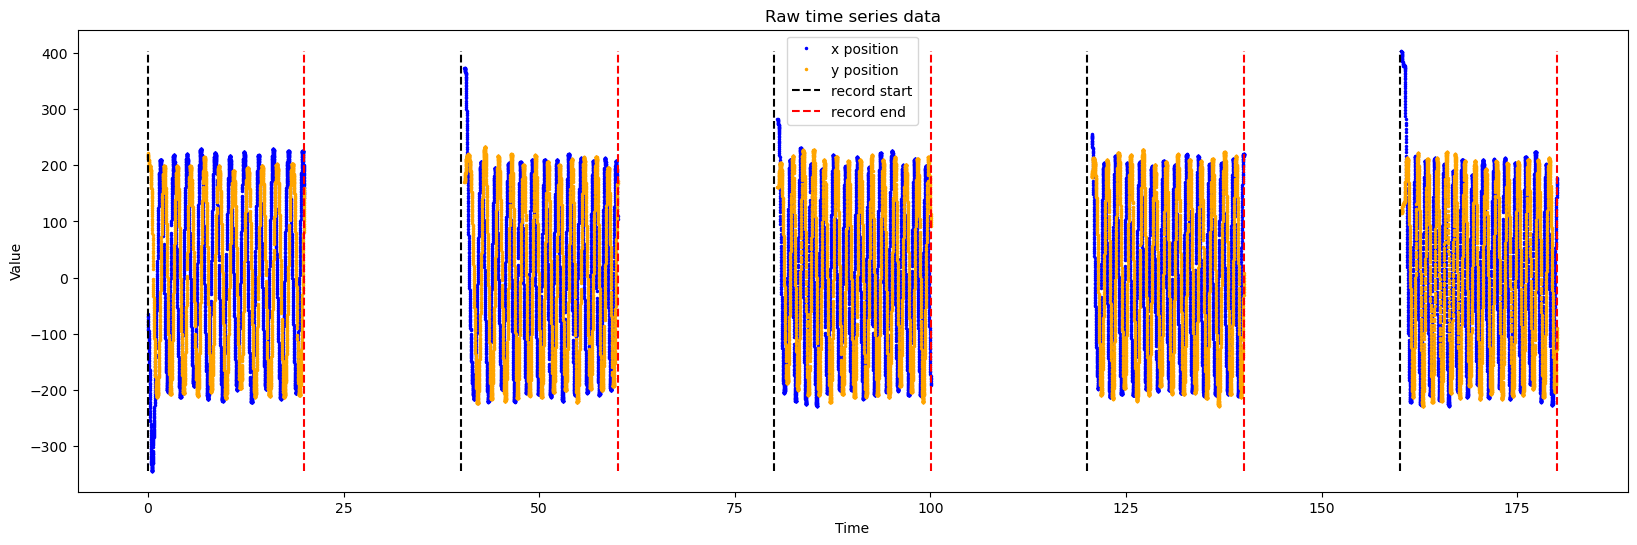

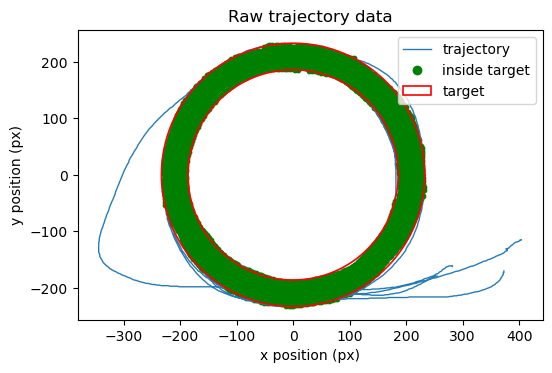

In [104]:
# ============================================================================
# 4. ALL DATA PLOTS
# ============================================================================

# Plot time series for all recordings
plot_all_data_timeseries(time_s, x_centered, y_centered, intervals)

# Plot spatial trajectory for all recordings
plot_all_data_spatial(x_centered, y_centered, inside_flag)

In [105]:
# ============================================================================
# 5. RECORDING INTERVALS ANALYSIS (with sampling frequency)
# ============================================================================

# Compute sampling frequency for each interval
freq_stats = compute_sampling_frequency(time_s, intervals)

print(f"\n{'Record':<8} {'Samples':<10} {'Duration (s)':<15} {'Frequency (Hz)':<15}")
print("-" * 50)
for rec_idx, n_samples, duration, freq in freq_stats:
    print(f"Rec {rec_idx:<4} {n_samples:<10} {duration:<15.3f} {freq:<15.2f}")

# Statistics summary
all_freqs = [freq for _, _, _, freq in freq_stats]
print(f"\nSampling frequency statistics:")
print(f"  Mean: {np.mean(all_freqs):.2f} Hz")
print(f"  Std:  {np.std(all_freqs, ddof=1):.2f} Hz")
print(f"  Min:  {np.min(all_freqs):.2f} Hz")
print(f"  Max:  {np.max(all_freqs):.2f} Hz")


Record   Samples    Duration (s)    Frequency (Hz) 
--------------------------------------------------
Rec 1    3971       20.003          198.52         
Rec 2    3898       20.011          194.79         
Rec 3    3898       20.014          194.76         
Rec 4    3884       20.014          194.06         
Rec 5    3936       20.014          196.66         

Sampling frequency statistics:
  Mean: 195.76 Hz
  Std:  1.82 Hz
  Min:  194.06 Hz
  Max:  198.52 Hz


In [106]:
# ============================================================================
# 6. RECOMPUTED STATISTICS
# ============================================================================

# Metrics table header (original format)
print(f"\n   {'Var':<6} , {'nLaps':>5} , {'Re':>8} , {'Te':>8} , {'error':>7} , {'MT/lap':>7} , {'IDe/lap':>7} , {'Be':>8} , {'IPe':>7}")
print(f"  {'unit':<6} , {'lap':>5} , {'pixel':>8} , {'pixel':>8} , {'%':>7} , {'s/lap':>7} , {'ratio':>7} , {'ratio':>8} , {'ratio':>7}")
print(f"{'Theory':<7} , {1.00:5.2f} , {task_radius:8.2f} , {task_tolerance:8.2f} , {3.88:7.2f} , {'':>7} , {'':>7} , {1.00:8.2f} , {'':>7}")

# Compute metrics for each recording
all_metrics = []
for i, (start, end) in enumerate(intervals):
    mask = (time_s >= start) & (time_s <= end)
    t_rec = time_s[mask]
    x_rec = x_centered[mask]
    y_rec = y_centered[mask]
    dist_rec = radial_dist[mask]
    inside_rec = inside_flag[mask]
    
    if len(t_rec) == 0:
        print(f"{'Rec'+str(i+1).zfill(3):<7} , {0:5.2f} , {0:8.2f} , {0:8.2f} , {np.nan:7.2f} , {np.nan:7.2f} , {np.nan:7.2f} , {0:8.2f} , {0:7.2f}")
        all_metrics.append(None)
        continue
    
    metrics = compute_metrics(t_rec, x_rec, y_rec, dist_rec, inside_rec, task_tolerance)
    all_metrics.append(metrics)
    
    if metrics is None:
        print(f"Warning: Rec{i+1:03d} - cursor never entered target")
        continue
    
    print(f"{'Rec'+str(i+1).zfill(3):<7} , "
          f"{metrics['nLaps']:5.2f} , {metrics['Re']:8.2f} , {metrics['Te']:8.2f} , "
          f"{metrics['error']:7.2f} , {metrics['MT']:7.2f} , {metrics['IDe']:7.2f} , "
          f"{metrics['Be']:8.2f} , {metrics['IPe']:7.2f}")


   Var    , nLaps ,       Re ,       Te ,   error ,  MT/lap , IDe/lap ,       Be ,     IPe
  unit   ,   lap ,    pixel ,    pixel ,       % ,   s/lap ,   ratio ,    ratio ,   ratio
Theory  ,  1.00 ,   209.50 ,    47.00 ,    3.88 ,         ,         ,     1.00 ,        
Rec001  , -10.84 ,   213.86 ,    91.79 ,    3.89 ,    1.84 ,   14.64 ,     1.95 ,    7.94
Rec002  , -11.97 ,   209.85 ,    34.46 ,    0.73 ,    1.59 ,   38.27 ,     0.73 ,   24.04
Rec003  , -13.26 ,   209.43 ,    42.42 ,    2.81 ,    1.45 ,   31.02 ,     0.90 ,   21.40
Rec004  , -12.83 ,   209.46 ,    37.14 ,    0.13 ,    1.49 ,   35.43 ,     0.79 ,   23.72
Rec005  , -14.74 ,   210.89 ,    43.88 ,    2.83 ,    1.30 ,   30.20 ,     0.93 ,   23.20


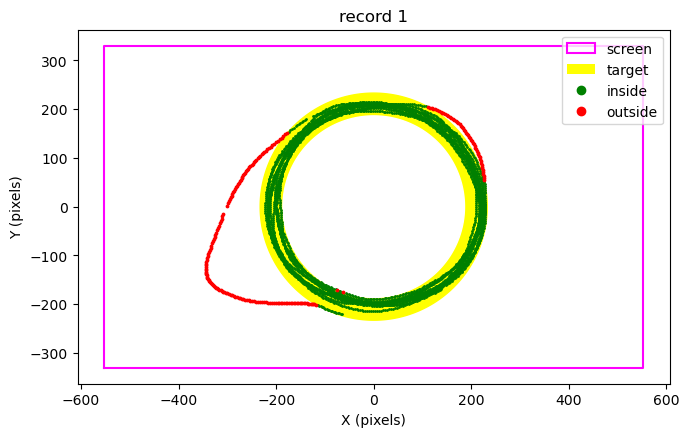

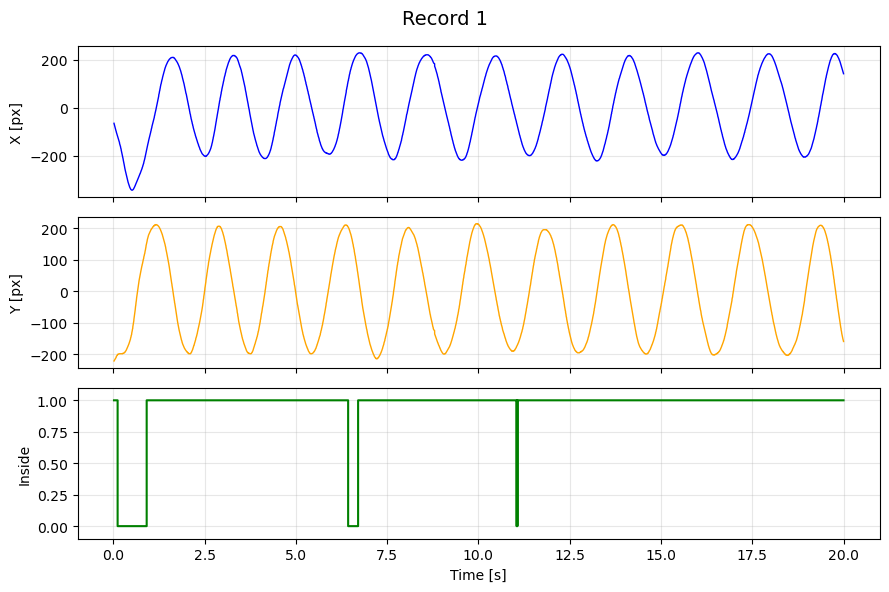

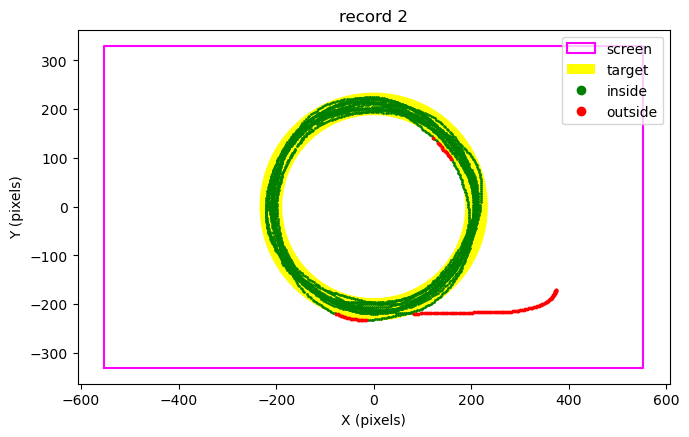

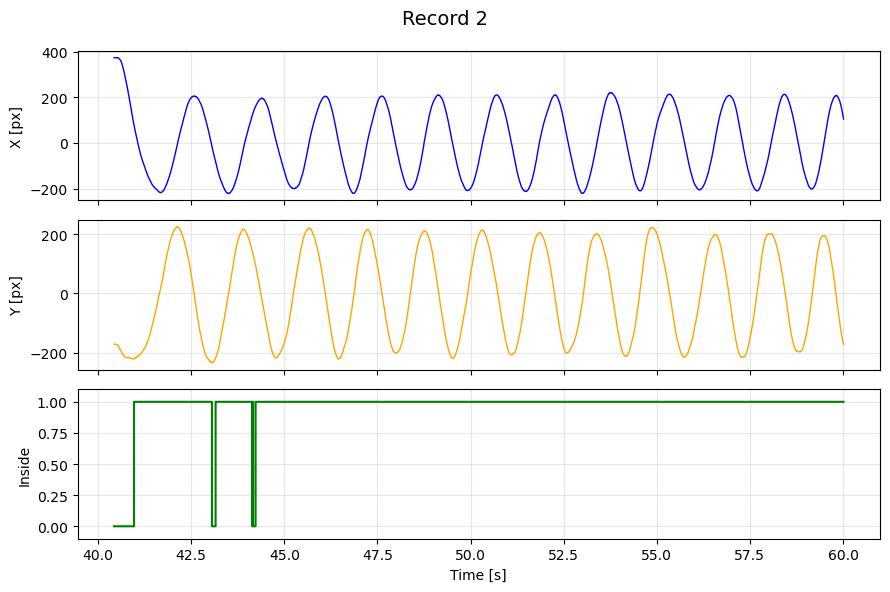

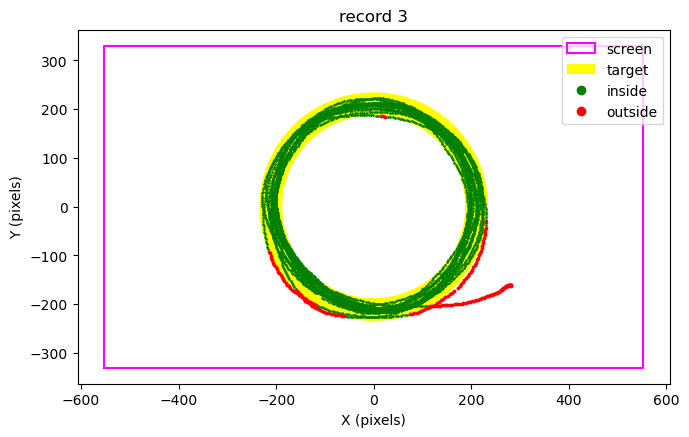

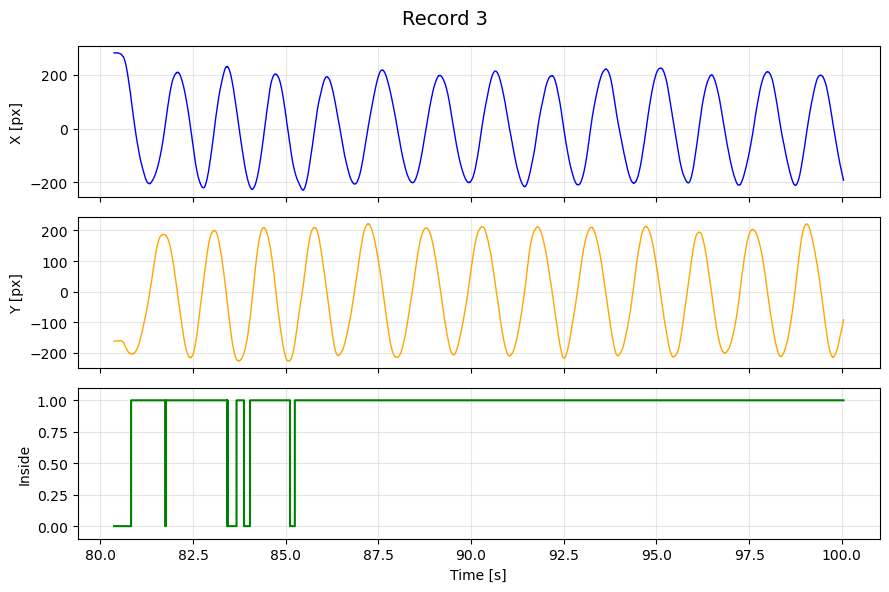

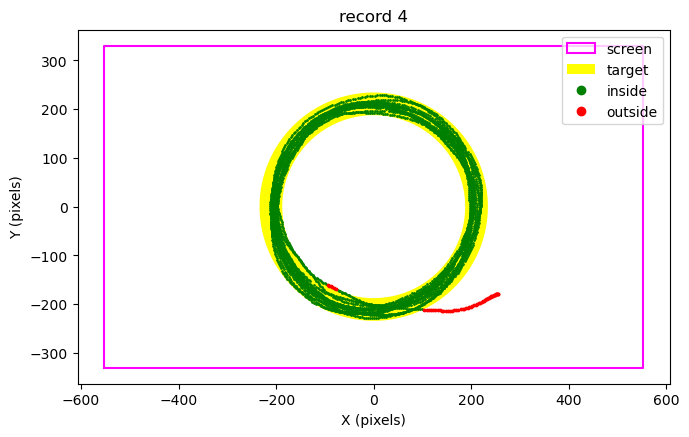

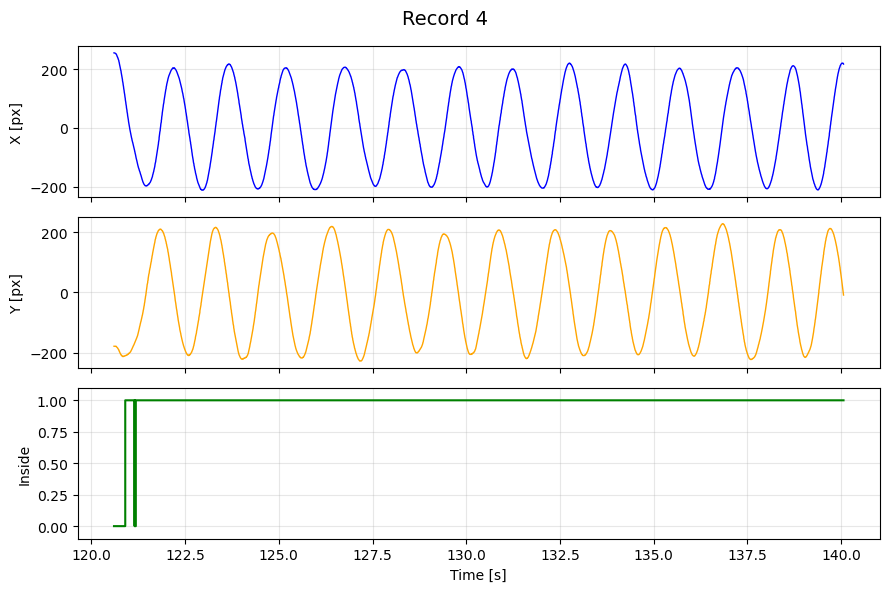

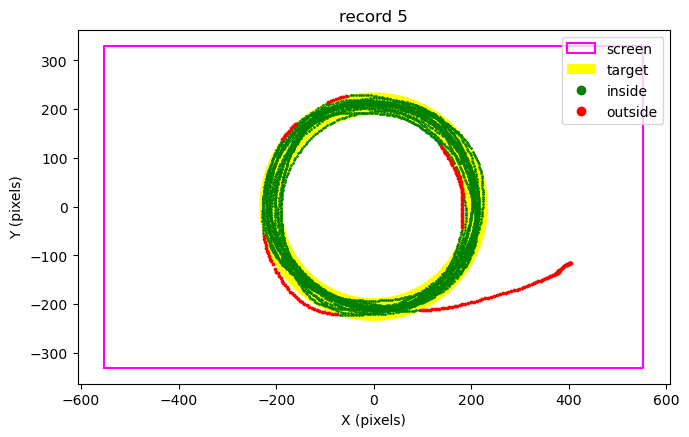

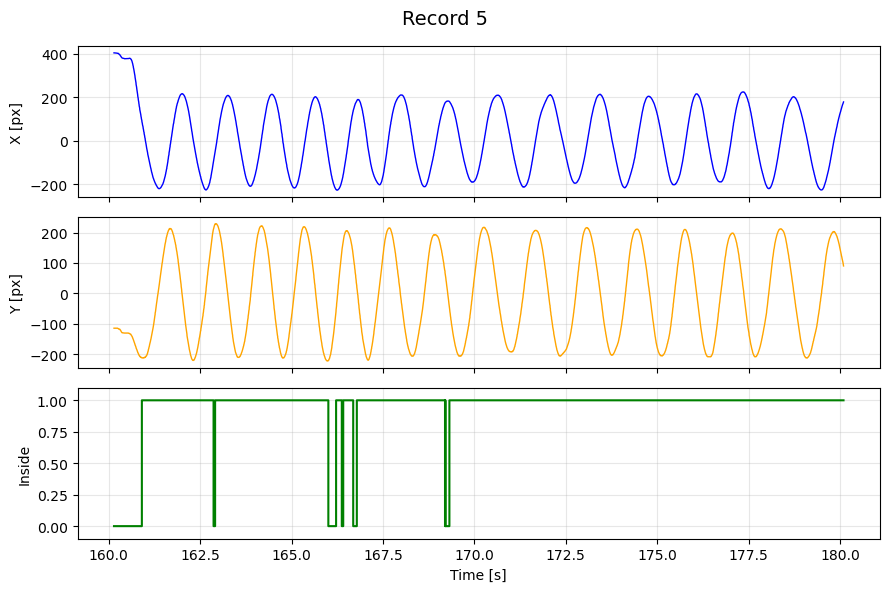

In [107]:
# ============================================================================
# 7. INDIVIDUAL RECORD PLOTS (alternating spatial and time-series)
# ============================================================================

for i, (start, end) in enumerate(intervals):
    rec_idx = i + 1
    
    # Plot spatial (on plane)
    plot_record_spatial(x_centered, y_centered, inside_flag, center_x, center_y,
                       rec_idx, start, end, time_s)
    
    # Plot time series
    plot_record_timeseries(time_s, x_centered, y_centered, inside_flag, 
                          rec_idx, start, end)